# Brussels Metro (STIB/MIVB) Geographic Data Ingestion

This notebook downloads the official geographic definitions (lines, stops/stations, underground station/tunnel footprints, and entrances) for the **Brussels Metro (STIB/MIVB)** in **GeoJSON** format (`EPSG:4326`) and ingests them into **GeoPandas `GeoDataFrame`s**.

## Data Sources Overview

1. **Brussels Mobility (Mobiris / Datastore.brussels) GeoServer WFS API** *(Primary, no API key required)*
   - **Portal:** [data.mobility.brussels](https://data.mobility.brussels/) / [datastore.brussels](https://datastore.brussels/)
   - **WFS Endpoint:** `https://data.mobility.brussels/geoserver/wfs`
   - **Direct GeoJSON Layers:**
     - `bm_public_transport:stib_lines` (`CQL_FILTER=mode='Metro'`): `MultiLineString` geometries for STIB Metro Lines **1, 2, 5, and 6** (both directions/variants), including official hex colors (`#B5378C`, `#ED6C23`, `#F6A90B`, `#0066A3`).
     - `bm_public_transport:stib_stops` (`CQL_FILTER=mode='Metro'`): `Point` geometries for all **124 STIB Metro platform stops** (**60 unique metro stations**) with `stop_id`, `line`, `name_fr`, and `name_nl`.
     - `bm_public_transport:Metro`: `Polygon` footprints of **69 underground Metro/Premetro stations** (`type='MS'`) and **87 tunnel segments** (`type='MT'`).

2. **City of Brussels Open Data Portal (Opendatasoft API v2.1)**
   - **Portal:** [opendata.brussels.be](https://opendata.brussels.be/)
   - **Dataset:** `entrees-stations-souterraines-metro-premetro-ingangen-ondergrondse-metro-premetro-stations`
   - **Direct GeoJSON Export:** `https://opendata.brussels.be/api/explore/v2.1/catalog/datasets/entrees-stations-souterraines-metro-premetro-ingangen-ondergrondse-metro-premetro-stations/exports/geojson`

3. **Additional GTFS & OpenStreetMap Sources**
   - **Official GTFS Static Feeds (`routes.txt`, `shapes.txt`, `stops.txt`):** [transportdata.be](https://transportdata.be/), [data.belgianmobility.io](https://data.belgianmobility.io/), and [mobilitytwin.brussels](https://mobilitytwin.brussels/).
   - **OpenStreetMap Overpass API:** Query `route=subway` and `railway=station` + `station=subway` within the Brussels-Capital Region.

In [16]:
import io
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

BRUSSELS_MOBILITY_WFS = "https://data.mobility.brussels/geoserver/wfs"

def fetch_wfs_geojson(type_name: str, cql_filter: str | None = None, srs: str = "EPSG:4326") -> gpd.GeoDataFrame:
    """Download a GeoJSON layer from Brussels Mobility WFS and ingest it into a GeoDataFrame."""
    params = {
        "service": "WFS",
        "version": "2.0.0",
        "request": "GetFeature",
        "typeName": type_name,
        "outputFormat": "application/json",
        "srsName": srs,
    }
    if cql_filter:
        params["CQL_FILTER"] = cql_filter

    response = requests.get(BRUSSELS_MOBILITY_WFS, params=params, timeout=30)
    response.raise_for_status()
    return gpd.read_file(io.BytesIO(response.content))

## 1. Download & Ingest Brussels Metro Lines (`bm_public_transport:stib_lines`)

Fetches the `MultiLineString` geometries for the 4 heavy metro lines (`1`, `2`, `5`, `6`) across both directions (`variant` 1 and 2), along with their official STIB hex colors.

In [2]:
# Download STIB Metro lines (mode='Metro') into a GeoDataFrame
gdf_metro_lines = fetch_wfs_geojson(
    type_name="bm_public_transport:stib_lines",
    cql_filter="mode='Metro'"
)

print(f"Loaded {len(gdf_metro_lines)} metro line variants (CRS: {gdf_metro_lines.crs})")
gdf_metro_lines

Loaded 8 metro line variants (CRS: EPSG:4326)


,id,ogc_fid,line,mode,variant,color,from_date,to_date,geometry
0,stib_lines.0,0,1,Metro,1,#B5378C,2026-03-02,2026-08-28,"MULTILINESTRING ((4.3209 50.849, 4.3211 50.849..."
1,stib_lines.1,1,1,Metro,2,#B5378C,2026-03-02,2026-08-28,"MULTILINESTRING ((4.4645 50.8419, 4.4636 50.84..."
2,stib_lines.2,2,2,Metro,1,#ED6C23,2026-03-02,2026-08-28,"MULTILINESTRING ((4.3305 50.8631, 4.3297 50.86..."
3,stib_lines.3,3,2,Metro,2,#ED6C23,2026-03-02,2026-08-28,"MULTILINESTRING ((4.3314 50.8629, 4.332 50.862..."
4,stib_lines.6,6,5,Metro,1,#F6A90B,2026-03-02,2026-08-28,"MULTILINESTRING ((4.2673 50.8152, 4.268 50.815..."
5,stib_lines.7,7,5,Metro,2,#F6A90B,2026-03-02,2026-08-28,"MULTILINESTRING ((4.4285 50.8122, 4.4281 50.81..."
6,stib_lines.8,8,6,Metro,1,#0066A3,2026-03-02,2026-08-28,"MULTILINESTRING ((4.328 50.8965, 4.329 50.8967..."
7,stib_lines.9,9,6,Metro,2,#0066A3,2026-03-02,2026-08-28,"MULTILINESTRING ((4.3314 50.8629, 4.332 50.862..."


In [18]:
gdf_metro_lines.to_parquet('../data/brussels_metro_lines.parquet')

## 2. Download & Ingest Brussels Metro Stops and Stations (`bm_public_transport:stib_stops`)

Fetches the 124 directional `Point` stop locations (`gdf_metro_stops`) and aggregates them by station name (`name_fr`, `name_nl`) to obtain a clean `GeoDataFrame` of the **60 unique Brussels Metro stations** (`gdf_metro_stations`) with their centroid coordinates and served lines.

In [7]:
# Download STIB Metro platform stops (mode='Metro') into a GeoDataFrame
gdf_metro_stops = fetch_wfs_geojson(
    type_name="bm_public_transport:stib_stops",
    cql_filter="mode='Metro'"
)

print(f"Loaded {len(gdf_metro_stops)} metro stop points across {gdf_metro_stops['name_fr'].nunique()} unique stations (CRS: {gdf_metro_stops.crs})")
gdf_metro_stops.head(10)

Loaded 124 metro stop points across 60 unique stations (CRS: EPSG:4326)


,id,gid,line,mode,stop_id,name_fr,name_nl,geometry
0,stib_stops.2313,2313,{1},Metro,8733,Gare de l'Ouest,Weststation,POINT (4.3209 50.849)
1,stib_stops.2314,2314,"{1,5}",Metro,8742,Beekkant,Beekkant,POINT (4.323 50.8534)
2,stib_stops.2315,2315,"{1,5}",Metro,8292,Étangs Noirs,Zwarte Vijvers,POINT (4.3331 50.8571)
3,stib_stops.2316,2316,"{1,5}",Metro,8282,Comte de Flandre,Graaf van Vlaanderen,POINT (4.3405 50.8547)
4,stib_stops.2317,2317,"{1,5}",Metro,8272,Sainte-Catherine,Sint-Katelijne,POINT (4.348 50.8519)
5,stib_stops.2318,2318,"{1,5}",Metro,8012,De Brouckère,De Brouckère,POINT (4.3525 50.8498)
6,stib_stops.2319,2319,"{1,5}",Metro,8022,Gare Centrale,Centraal Station,POINT (4.3588 50.8463)
7,stib_stops.2320,2320,"{1,5}",Metro,8032,Parc,Park,POINT (4.363 50.8457)
8,stib_stops.2321,2321,"{1,5}",Metro,8042,Arts-Loi,Kunst-Wet,POINT (4.3696 50.8453)
9,stib_stops.2322,2322,"{1,5}",Metro,8052,Maelbeek,Maalbeek,POINT (4.3776 50.8437)


In [8]:
# Aggregate directional platform stops into unique Metro stations (1 Point per station)
def merge_lines(series: pd.Series) -> str:
    lines = set()
    for val in series.dropna():
        for item in str(val).strip("{}").split(","):
            if item.strip():
                lines.add(item.strip())
    return ",".join(sorted(lines, key=lambda x: int(x) if x.isdigit() else x))

gdf_metro_stations = (
    gdf_metro_stops.dissolve(
        by=["name_fr", "name_nl"],
        aggfunc={
            "stop_id": lambda s: ",".join(sorted(set(s.astype(str)))),
            "line": merge_lines,
        },
    )
    .reset_index()
)
# Convert MultiPoint platform clusters to their geographic centroid Point
gdf_metro_stations["geometry"] = gdf_metro_stations.geometry.centroid

print(f"Unique Metro stations: {len(gdf_metro_stations)}")
gdf_metro_stations.head(10)

Unique Metro stations: 60


/tmp/ipykernel_3390781/2828176834.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_metro_stations["geometry"] = gdf_metro_stations.geometry.centroid


,name_fr,name_nl,geometry,stop_id,line
0,Alma,Alma,POINT (4.45325 50.84995),"8141,8142",1
1,Arts-Loi,Kunst-Wet,POINT (4.36908 50.84545),"8041,8042,8401,8402","1,2,5,6"
2,Aumale,Aumale,POINT (4.3123 50.8396),"8711,8712",5
3,Beaulieu,Beaulieu,POINT (4.40965 50.8151),"8241,8242",5
4,Beekkant,Beekkant,POINT (4.32292 50.85332),"8741,8742,8743,8744","1,2,5,6"
5,Belgica,Belgica,POINT (4.33695 50.8685),"8773,8774",6
6,Bizet,Bizet,POINT (4.29735 50.82505),"8681,8682",5
7,Bockstael,Bockstael,POINT (4.3479 50.87915),"8793,8794",6
8,Botanique,Kruidtuin,POINT (4.36545 50.85405),"8421,8422","2,6"
9,CERIA,COOVI,POINT (4.28965 50.81635),"8661,8662",5


In [19]:
gdf_metro_stations.to_parquet('../data/brussels_metro_stations.parquet')

## 3. Download Underground Station/Tunnel Footprints & Entrances

- **`bm_public_transport:Metro` (Brussels Mobility WFS):** `Polygon` geometries for **69 underground metro/premetro stations** (`type == 'MS'`) and **87 tunnel segments** (`type == 'MT'`).
- **City of Brussels Open Data (`opendata.brussels.be`):** `Point` geometries for **109 underground metro/premetro station entrances**.

In [9]:
# 3a. Underground station footprints ('MS') and tunnel polygons ('MT')
gdf_metro_polygons = fetch_wfs_geojson(type_name="bm_public_transport:Metro")
print(
    f"Loaded {len(gdf_metro_polygons)} underground polygons: "
    f"{(gdf_metro_polygons['type'] == 'MS').sum()} stations (MS), "
    f"{(gdf_metro_polygons['type'] == 'MT').sum()} tunnels (MT)"
)

# 3b. Underground metro/premetro station entrances (City of Brussels Open Data GeoJSON)
ENTRANCES_GEOJSON_URL = (
    "https://opendata.brussels.be/api/explore/v2.1/catalog/datasets/"
    "entrees-stations-souterraines-metro-premetro-ingangen-ondergrondse-metro-premetro-stations/"
    "exports/geojson"
)
gdf_metro_entrances = gpd.read_file(ENTRANCES_GEOJSON_URL)
print(f"Loaded {len(gdf_metro_entrances)} station entrance points (CRS: {gdf_metro_entrances.crs})")
gdf_metro_polygons[gdf_metro_polygons["type"] == "MS"].head(5)

Loaded 156 underground polygons: 69 stations (MS), 87 tunnels (MT)
Loaded 109 station entrance points (CRS: EPSG:4326)


,id,ogc_fid,name_fr,name_nl,niveau,type,geometry
0,Metro.1,1,Station Montgomery,Station Montgomery,-,MS,"POLYGON ((4.41 50.8383, 4.4099 50.8383, 4.4098..."
2,Metro.3,3,Station Thieffry,Station Thieffry,-,MS,"POLYGON ((4.4016 50.8342, 4.4022 50.8327, 4.40..."
3,Metro.4,4,Station Stockel,Station Stokkel,-,MS,"POLYGON ((4.4638 50.8425, 4.4638 50.8425, 4.46..."
5,Metro.6,6,Station Albert,Station Albert,-,MS,"POLYGON ((4.3415 50.821, 4.3414 50.8211, 4.341..."
6,Metro.7,7,Station Stuyvenbergh,Station Stuyvenbergh,-,MS,"POLYGON ((4.3413 50.8866, 4.3414 50.8866, 4.34..."


## 4. Plot the Brussels Metro Network (Lines & Stations)

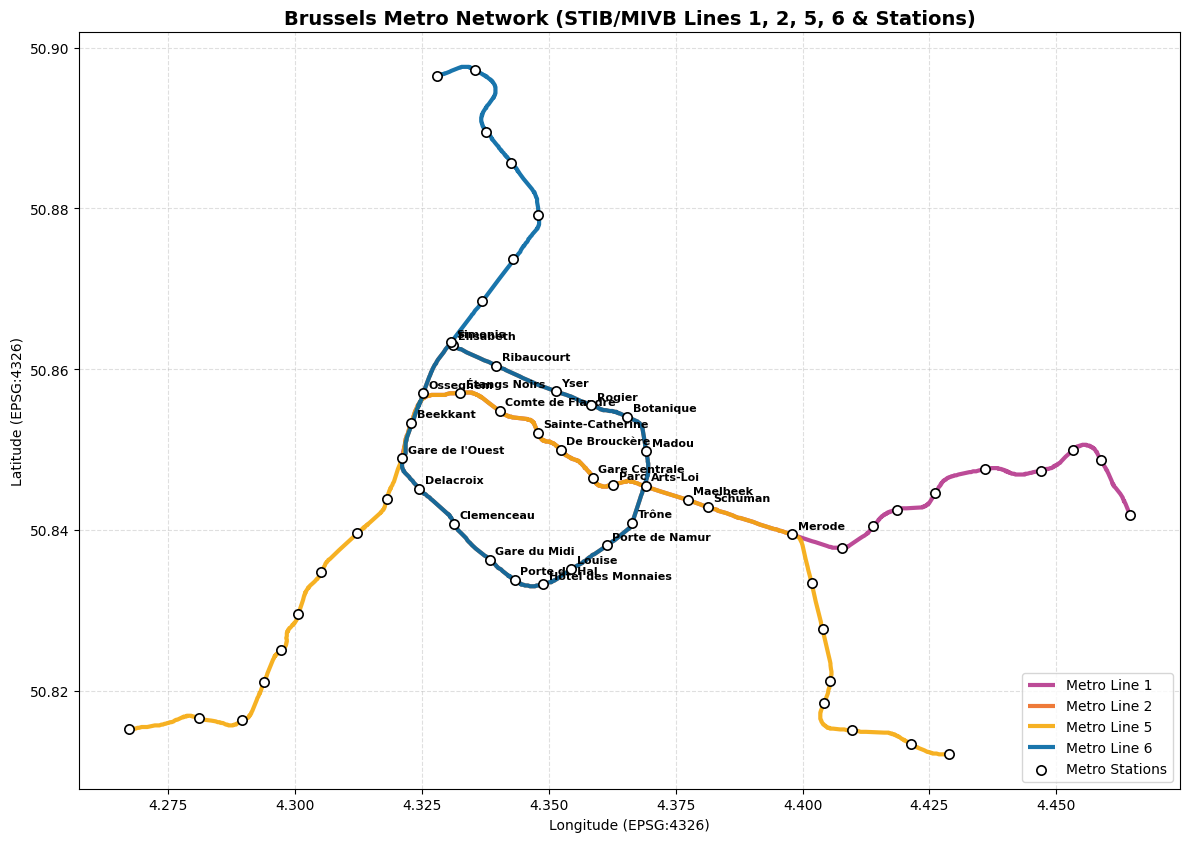

In [10]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot each metro line using its official STIB hex color
for line_id, group in gdf_metro_lines[gdf_metro_lines["variant"] == 1].groupby("line"):
    color = group["color"].iloc[0]
    group.plot(ax=ax, color=color, linewidth=3.0, label=f"Metro Line {line_id}", alpha=0.9)

# Plot unique metro station centroids
gdf_metro_stations.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    markersize=45,
    linewidth=1.2,
    zorder=5,
    label="Metro Stations",
)

# Annotate station names for key interchange stations
interchanges = gdf_metro_stations[gdf_metro_stations["line"].str.contains(",")]
for _, row in interchanges.iterrows():
    ax.annotate(
        row["name_fr"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
    )

ax.set_title("Brussels Metro Network (STIB/MIVB Lines 1, 2, 5, 6 & Stations)", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude (EPSG:4326)")
ax.set_ylabel("Latitude (EPSG:4326)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
gdf_metro_stations.shape, gdf_metro_stops.shape

((60, 5), (124, 8))

In [15]:
gdf_metro_stations

,name_fr,name_nl,geometry,stop_id,line
0,Alma,Alma,POINT (4.45325 50.84995),"8141,8142",1
1,Arts-Loi,Kunst-Wet,POINT (4.36908 50.84545),"8041,8042,8401,8402","1,2,5,6"
2,Aumale,Aumale,POINT (4.3123 50.8396),"8711,8712",5
3,Beaulieu,Beaulieu,POINT (4.40965 50.8151),"8241,8242",5
4,Beekkant,Beekkant,POINT (4.32292 50.85332),"8741,8742,8743,8744","1,2,5,6"
5,Belgica,Belgica,POINT (4.33695 50.8685),"8773,8774",6
6,Bizet,Bizet,POINT (4.29735 50.82505),"8681,8682",5
7,Bockstael,Bockstael,POINT (4.3479 50.87915),"8793,8794",6
8,Botanique,Kruidtuin,POINT (4.36545 50.85405),"8421,8422","2,6"
9,CERIA,COOVI,POINT (4.28965 50.81635),"8661,8662",5
